# ❤️ Heart Disease Prediction

This project predicts whether a person is likely to have heart disease based on medical attributes using Machine Learning models.

## Objectives
- Analyze heart disease dataset
- Perform data visualization
- Train multiple ML models
- Compare performance
- Build a prediction system

Import + Load Data

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [106]:
dataset = pd.read_csv("heart.csv")
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


#### Shape of dataset

In [107]:
dataset.shape

(1025, 14)

#### Printing out a few columns

In [108]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


#### Description

In [109]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Check Null Values

In [110]:
dataset.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [111]:
dataset["target"].unique()

array([0, 1])

## Exploratory Data Analysis (EDA)

###Target Distribution

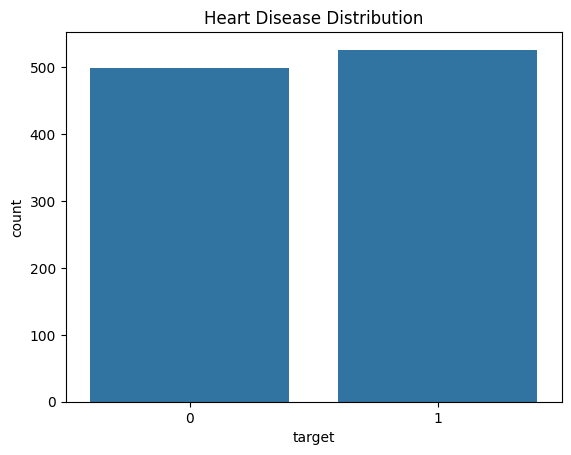

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=dataset)
plt.title("Heart Disease Distribution")
plt.show()

### Insight :
Balanced dataset with presence/absence of disease.

###Gender vs Disease

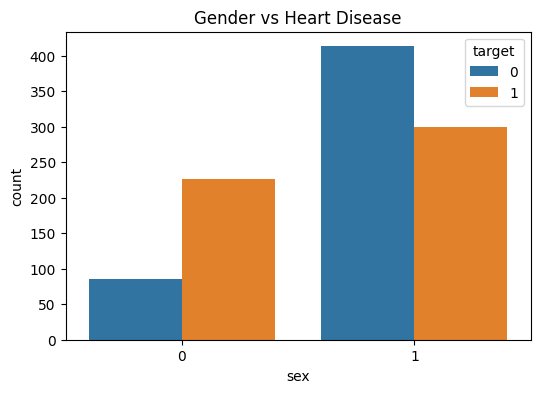

In [113]:
plt.figure(figsize=(6,4))
sns.countplot(x='sex', hue='target', data=dataset)
plt.title("Gender vs Heart Disease")
plt.show()

###Heat Map

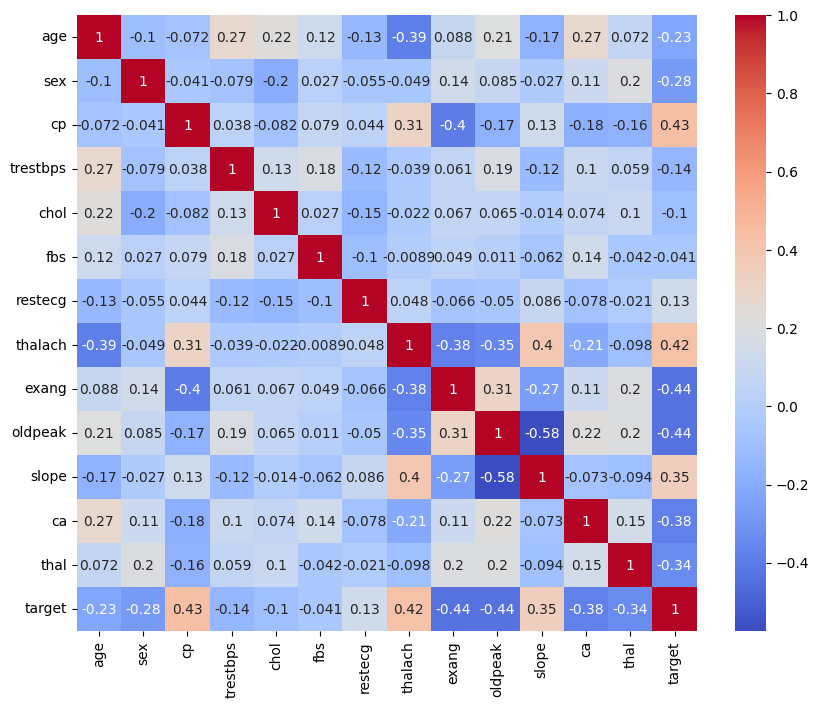

In [114]:
plt.figure(figsize=(10,8))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm')
plt.show()

###Age Distribution vs Heart Disease

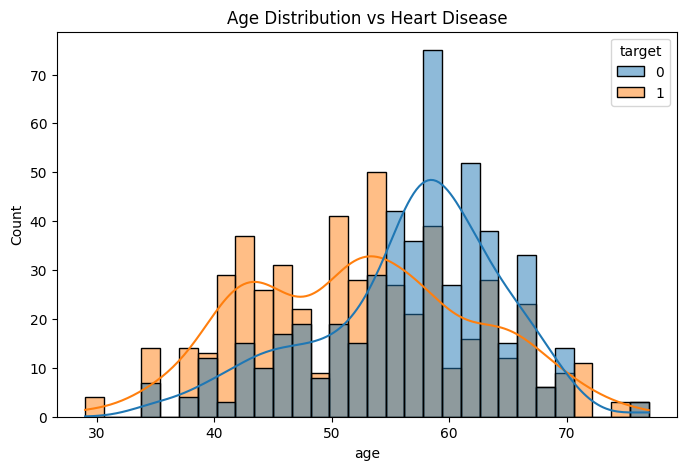

In [115]:
plt.figure(figsize=(8,5))
sns.histplot(data=dataset, x='age', hue='target', bins=30, kde=True)
plt.title("Age Distribution vs Heart Disease")
plt.show()

###Age vs Cholesterol

In [116]:
import plotly.express as px

fig = px.scatter(dataset, x="age", y="chol", color="target",
                 title="Age vs Cholesterol (Interactive)")
fig.show()

### First, analysing the target variable:

In [117]:
y = dataset["target"]
y


,target
0,0
1,0
2,0
3,0
4,0
...,...
1020,1
1021,0
1022,0
1023,1


###Data Preprocessing

In [118]:
from sklearn.model_selection import train_test_split

X = dataset.drop("target", axis=1)
y = dataset["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Data Distribution

In [119]:
X_train.shape
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
835,49,1,2,118,149,0,0,126,0,0.8,2,3,2
137,64,0,0,180,325,0,1,154,1,0.0,2,0,2
534,54,0,2,108,267,0,0,167,0,0.0,2,0,2
495,59,1,0,135,234,0,1,161,0,0.5,1,0,3
244,51,1,2,125,245,1,0,166,0,2.4,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,41,1,2,130,214,0,0,168,0,2.0,1,0,2
71,61,1,0,140,207,0,0,138,1,1.9,2,1,3
106,51,1,0,140,299,0,1,173,1,1.6,2,0,3
270,43,1,0,110,211,0,1,161,0,0.0,2,0,3


In [120]:
X_test.shape

(205, 13)

In [121]:
y_train.shape

(820,)

In [122]:
y_test.shape

(205,)

### Logistic Regression


===== Logistic Regression Results =====

Accuracy: 0.7951

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



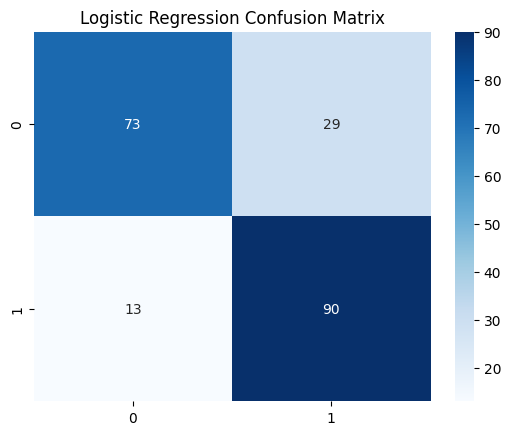

In [123]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\n===== Logistic Regression Results =====\n")

print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [124]:
score_lr = round(accuracy_score(y_pred_lr,y_test)*100,2)

print("The accuracy score achieved using Logistic Regression is: "+str(score_lr)+" %")

The accuracy score achieved using Logistic Regression is: 79.51 %


In [125]:
a = round(lr.score(X_train, y_train)*100,2)
b = round(lr.score(X_test, y_test)*100,2)
print("Train Accuracy : "+str(a)+" %")
print("Test Accuracy : "+str(b)+" %")

Train Accuracy : 87.2 %
Test Accuracy : 79.51 %


### Decision Tree


===== Decision Tree Results =====

Accuracy: 0.9854

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



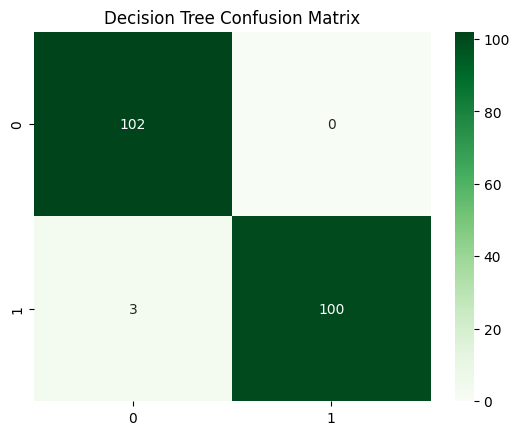

In [126]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("\n===== Decision Tree Results =====\n")

print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [127]:
score_dt = round(accuracy_score(y_pred_dt,y_test)*100,2)

print("The accuracy score achieved using Decision Tree is: "+str(score_dt)+" %")

The accuracy score achieved using Decision Tree is: 98.54 %


In [128]:
a = round(dt.score(X_train, y_train)*100,2)
b = round(dt.score(X_test, y_test)*100,2)
print("Train Accuracy : "+str(a)+" %")
print("Test Accuracy : "+str(b)+" %")

Train Accuracy : 100.0 %
Test Accuracy : 98.54 %


In [129]:
#Decision Tree(controling Overfitting)
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=5,
    ccp_alpha=0.01,
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

a = round(dt.score(X_train, y_train)*100,2)
b = round(dt.score(X_test, y_test)*100,2)
print("Train Accuracy : "+str(a)+" %")
print("Test Accuracy : "+str(b)+" %")

Train Accuracy : 87.8 %
Test Accuracy : 79.02 %


### Random Forest


===== Random Forest Results =====

Accuracy: 0.9854

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



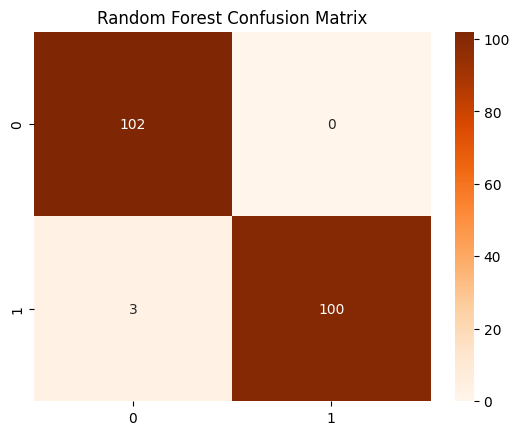

In [130]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n===== Random Forest Results =====\n")

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Random Forest Confusion Matrix")
plt.show()

In [131]:
score_rf = round(accuracy_score(y_pred_rf,y_test)*100,2)

print("The accuracy score achieved using Random Forest is: "+str(score_rf)+" %")

The accuracy score achieved using Random Forest is: 98.54 %


In [132]:
a = round(rf.score(X_train, y_train)*100,2)
b = round(rf.score(X_test, y_test)*100,2)
print("Train Accuracy : "+str(a)+" %")
print("Test Accuracy : "+str(b)+" %")

Train Accuracy : 100.0 %
Test Accuracy : 98.54 %


In [133]:
# Random Forest(controling Overfitting)
rf = RandomForestClassifier(
    n_estimators=10,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

# Train
rf.fit(X_train, y_train)
a = round(rf.score(X_train, y_train)*100,2)
b = round(rf.score(X_test, y_test)*100,2)
print("Train Accuracy : "+str(a)+" %")
print("Test Accuracy : "+str(b)+" %")

Train Accuracy : 91.95 %
Test Accuracy : 84.88 %


Feature Importance

In [134]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf.feature_importances_
features = X.columns

imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=True)

print(imp_df)

     Feature  Importance
6    restecg    0.004177
5        fbs    0.006516
1        sex    0.031388
3   trestbps    0.033023
10     slope    0.037586
0        age    0.055660
4       chol    0.057511
8      exang    0.099787
2         cp    0.120411
12      thal    0.124559
9    oldpeak    0.132591
7    thalach    0.140604
11        ca    0.156185


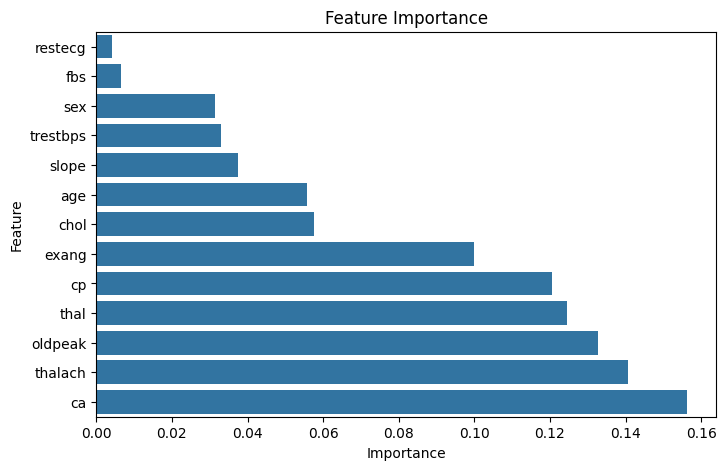

In [135]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=imp_df)
plt.title("Feature Importance")
plt.show()

### K Nearest Neighbors


===== K Nearest Neighbors Results =====

Accuracy: 0.7317

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.73      0.73       102
           1       0.73      0.74      0.73       103

    accuracy                           0.73       205
   macro avg       0.73      0.73      0.73       205
weighted avg       0.73      0.73      0.73       205



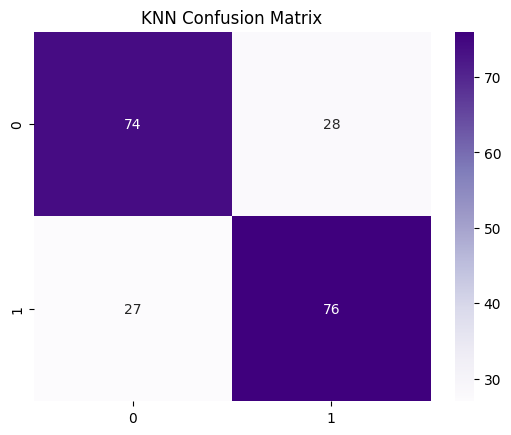

In [136]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("\n===== K Nearest Neighbors Results =====\n")

print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("KNN Confusion Matrix")
plt.show()

In [137]:
score_knn = round(accuracy_score(y_pred_knn,y_test)*100,2)

print("The accuracy score achieved using KNN is: "+str(score_knn)+" %")

The accuracy score achieved using KNN is: 73.17 %


In [138]:
a = round(knn.score(X_train, y_train)*100,2)
b = round(knn.score(X_test, y_test)*100,2)
print("Train Accuracy : "+str(a)+" %")
print("Test Accuracy : "+str(b)+" %")

Train Accuracy : 92.32 %
Test Accuracy : 73.17 %


###Model Comparison

In [139]:
results = {
    "LR": round(lr.score(X_test, y_test)*100,2),
    "DT": round(dt.score(X_test, y_test)*100,2),
    "RF": round(rf.score(X_test, y_test)*100,2),
    "KNN": round(knn.score(X_test, y_test)*100,2)
}

print(results)

{'LR': 79.51, 'DT': 79.02, 'RF': 84.88, 'KNN': 73.17}


In [142]:
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

X = dataset.drop('target', axis=1)
y = dataset['target']

scaler = StandardScaler()
X = scaler.fit_transform(X)

model = RandomForestClassifier()
model.fit(X, y)

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Files created!")

Files created!


In [143]:
from google.colab import files

files.download("model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###Conclusion

- Random Forest performed best
- Overfitting controlled using hyperparameters
- Model useful for early prediction